# Введення в PyTorch і персептрон

*pip install torch*

Перцептрон (персептрон) - модель, що діє схожим з біологією принципом "збудження" і його передачі далі.
Складаються з вхідного шару - сенсорів, проміжних (прихованих) шарів та вихідного шару - вирішувача.

Навчання перцептрона - процес підбору, коригування вагових коефіцієнтів зв'язків, що поєднують проміжні та вихідні шари. Розрізняють "прямий" хід навчання, коли збільшуються (або зменшуються) коефіцієнти для усіх активованих елементів при "демонстрації" прикладів різних класів. Та "зворотній" хід, коли результат зміни втрат впливає на коригування коефіцієнтів. (Втрати - оцінка помилок передбачення). Для реалізації зворотного ходу необхідно забезпечувати збереження відомостей про попередні стани коефіцієнтів для чого потрібні спеціалізовані типи даних - тензори.

In [1]:
import torch

## Бізнес-контекст
Компанія HealthRisk Analytics будує прототип моделі, яка за простими показниками (наприклад, вік та індекс маси тіла) прогнозує рівень страхового ризику клієнта.

Ваше завдання — змоделювати основу цієї системи, використовуючи PyTorch: спочатку — один лінійний нейрон, потім — малу нейромережу.

*Навчання перцептронів та нейромереж здійснюється у певному бізнес-контексті. Одним з недоліків нейромереж є їх сильна залежність від "масштабу" - представлення даних, що обробляються.*

## Завдання 1
Створіть тензори та виконайте базові операції.
Уявіть, що кожен тензор — це стовпець даних про клієнтів (вік, вага, зріст).
- Створіть 1D, 2D і 3D тензори(torch.manual_seed(42)).
- Виконайте операції додавання і поелементного множення, щоб обчислити умовний показник ризику.
- Увімкніть requires_grad=True для одного тензора, перевірте наявність grad_fn.

In [2]:
# сідування (seed, seeding) - встановлення початкового стану генераторів випадкових чисел для 
# забезпечення відновлюваності експериментів
torch.manual_seed(42)

# Створіть 1D (вік)
age = torch.randint(18, 75, (5,))
age

tensor([33, 50, 67, 70, 39])

In [3]:
# Створіть 2D (вік, вага)
age_weight = torch.randn(5, 2)  # n - normal distribution
age_weight[:,0] = 42 + 21 * age_weight[:,0]
age_weight[:,1] = 75 + 25 * age_weight[:,1]
age_weight

tensor([[48.8408, 53.3093],
        [73.9858, 91.6166],
        [20.3186, 68.0742],
        [38.4902, 72.3026],
        [12.0008, 67.9757]])

In [4]:
# Створіть 3D (вік, вага, зріст)
age_weight_height = torch.randn(5, 3, requires_grad=True) 
# включення стеження за градієнтом забороняє прямі операції з перетворення вмісту тензора
# за потреби таких змін слід відключити стеження за градієнтом
with torch.no_grad() :
    age_weight_height[:,0] = 42 + 21 * age_weight_height[:,0]
    age_weight_height[:,1] = 75 + 25 * age_weight_height[:,1]
    age_weight_height[:,2] = 155 + 15 * age_weight_height[:,2]
age_weight_height

tensor([[ 57.7275, 102.9106, 174.3963],
        [ 50.6882,  60.7250, 140.3758],
        [ 45.9132, 115.6815, 171.8216],
        [ 28.1287,  74.6736, 178.7896],
        [ 20.6092,  64.5493, 150.5975]], requires_grad=True)

In [5]:
# Виконайте операції додавання і поелементного множення, щоб обчислити умовний показник ризику.
risk = 2 * age_weight_height[:,0] + 3 * (age_weight_height[:,1] - 75) + 0.01 * age_weight_height[:,2]
risk

tensor([200.9306,  59.9552, 215.5892,  57.0662,  11.3721],
       grad_fn=<AddBackward0>)

## Завдання 2
Реалізуйте персептрон для передбачення ризику клієнта.

- Згенеруйте дані (torch.randn, 100 зразків, 1 ознака — індекс маси тіла).
- Цільова змінна — умовний "ризик" (лінійна комбінація + шум).
- Побудуйте модель nn.Linear(1, 1) і функцію втрат MSE.
- Виконайте 20 епох навчання з ручним оновленням параметрів.
- Виведіть початкові та фінальні значення ваг і loss.

In [6]:
# Згенеруйте дані (torch.randn, 100 зразків, 1 ознака — індекс маси тіла).
bmi = torch.randn(100, 1)
print(bmi[:5])

tensor([[-0.9224],
        [ 1.8113],
        [ 0.1606],
        [ 0.3672],
        [ 0.1754]])


In [7]:
# Цільова змінна — умовний "ризик" (лінійна комбінація + шум).
noise = 0.1 * torch.randn(100, 1)
risk = 2 + 5 * bmi + noise
print(risk[:5])

tensor([[-2.6069],
        [10.9980],
        [ 2.7638],
        [ 3.8398],
        [ 2.8891]])


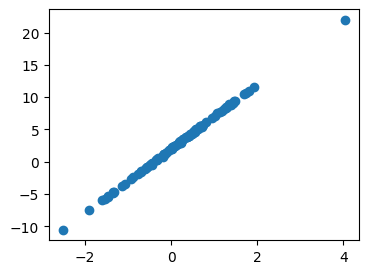

In [8]:
import matplotlib.pyplot as plt
_, ax = plt.subplots(figsize=(4,3))
ax.scatter(bmi, risk)
plt.show()

In [9]:
# Побудуйте модель nn.Linear(1, 1) і функцію втрат MSE.
import torch.nn as nn 
import torch.optim as optim 

class Percentrone(nn.Module):
    def __init__(self):
        super(Percentrone, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 1),
            # nn.ReLU()
        )
            

    def forward(self, x):
        x = self.layers(x)
        return x

loss_f = nn.functional.mse_loss

In [10]:
model = Percentrone()
print(*model.parameters(), sep="\n")

Parameter containing:
tensor([[-0.1569]], requires_grad=True)
Parameter containing:
tensor([-0.1139], requires_grad=True)


In [11]:
# Виконайте 20 епох навчання з ручним оновленням параметрів.
learning_rate = 0.1
loss_1 = []
for epoch in range(20):
    output= model(bmi)
    loss = loss_f(output, risk)
    loss.backward()

    with torch.no_grad():
        for param in model.parameters():
            param -= (
                learning_rate * 
                param.grad)
            param.grad.zero_()
    print(f"Epoch {epoch}, loss {loss.item()}")
    loss_1.append(loss.item())

Epoch 0, loss 33.37004089355469
Epoch 1, loss 20.380233764648438
Epoch 2, loss 12.502535820007324
Epoch 3, loss 7.7083563804626465
Epoch 4, loss 4.779179573059082
Epoch 5, loss 2.981543779373169
Epoch 6, loss 1.872886061668396
Epoch 7, loss 1.1854240894317627
Epoch 8, loss 0.7566143870353699
Epoch 9, loss 0.48743659257888794
Epoch 10, loss 0.3173200488090515
Epoch 11, loss 0.20904502272605896
Epoch 12, loss 0.13962455093860626
Epoch 13, loss 0.09478317201137543
Epoch 14, loss 0.0656004250049591
Epoch 15, loss 0.04646757245063782
Epoch 16, loss 0.03383297845721245
Epoch 17, loss 0.025431528687477112
Epoch 18, loss 0.019808266311883926
Epoch 19, loss 0.01602129638195038


In [12]:
print(*model.parameters(), sep="\n")

Parameter containing:
tensor([[4.9182]], requires_grad=True)
Parameter containing:
tensor([2.0279], requires_grad=True)


## Завдання 3
Навчіть той самий персептрон з оптимізатором SGD, щоб прискорити збіжність.

- Налаштуйте torch.optim.SGD(lr = 0.01).
- Виконайте 20 епох, фіксуючи loss.
- Заповніть таблицю:

Епоха|Loss|Loss(SGD)|
|-|-|-|
|1|...|...|
|...|
...|20|...

In [13]:
model2 = Percentrone()
loss_2 = []
optimizer = optim.SGD(model2.parameters(), lr = 0.1)
for epoch in range(20):
    output2 = model2(bmi)
    loss = loss_f(output2, risk)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}, loss {loss.item()}")
    loss_2.append(loss.item())

Epoch 0, loss 41.49073791503906
Epoch 1, loss 25.061952590942383
Epoch 2, loss 15.183856010437012
Epoch 3, loss 9.231098175048828
Epoch 4, loss 5.634517669677734
Epoch 5, loss 3.4550352096557617
Epoch 6, loss 2.1298086643218994
Epoch 7, loss 1.320908546447754
Epoch 8, loss 0.8250311017036438
Epoch 9, loss 0.5195796489715576
Epoch 10, loss 0.33042606711387634
Epoch 11, loss 0.21261072158813477
Epoch 12, loss 0.1387685239315033
Epoch 13, loss 0.09217753261327744
Epoch 14, loss 0.06257420778274536
Epoch 15, loss 0.04362722486257553
Epoch 16, loss 0.0314103364944458
Epoch 17, loss 0.023473793640732765
Epoch 18, loss 0.018279483541846275
Epoch 19, loss 0.014855112880468369


In [14]:
from IPython.display import Markdown as md
md("\n".join((
    "Епоха|Loss|Loss(SGD)",
    "|-|-|-|",
    *(f"|{epoch}|{loss_1[epoch]:.2f}|{loss_2[epoch]:.2f}" for epoch in range(20))
)))

Епоха|Loss|Loss(SGD)
|-|-|-|
|0|33.37|41.49
|1|20.38|25.06
|2|12.50|15.18
|3|7.71|9.23
|4|4.78|5.63
|5|2.98|3.46
|6|1.87|2.13
|7|1.19|1.32
|8|0.76|0.83
|9|0.49|0.52
|10|0.32|0.33
|11|0.21|0.21
|12|0.14|0.14
|13|0.09|0.09
|14|0.07|0.06
|15|0.05|0.04
|16|0.03|0.03
|17|0.03|0.02
|18|0.02|0.02
|19|0.02|0.01

## Завдання 4
Побудуйте графік залежності втрат від епох і зробіть висновок:

- Як швидко знижується помилка?
- Який діапазон ваг забезпечує мінімальний ризик?
- Збережіть графік у файл loss_healthrisk.png.

AttributeError: 'Axes' object has no attribute 'set_xtitle'

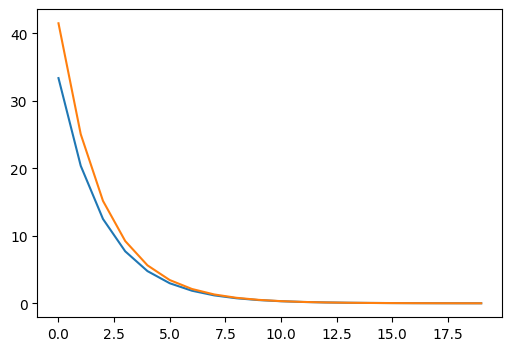

In [19]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(range(20), loss_1, label="No optimizer")
ax.plot(range(20), loss_2, label="SGD optimizer")
ax.set_xtitle("epoch")
ax.set_ytitle("loss")
ax.legend()
plt.show()

In [16]:
print(*model.parameters(), *model2.parameters())

Parameter containing:
tensor([[4.9182]], requires_grad=True) Parameter containing:
tensor([2.0279], requires_grad=True) Parameter containing:
tensor([[4.9230]], requires_grad=True) Parameter containing:
tensor([2.0183], requires_grad=True)
